# Over-sampled XGBoost Confidence Regression

BSD10k ?? ???? ?? train/validation/test? ?? ?, train ?????? confidence 2 ??? ???? confidence 1? random oversampling, confidence 3/4/5? random downsampling?? ?? XGBoost regression ???? ??? ??/???? ?????.

In [1]:
from pathlib import Path
import os
import sys
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, mean_absolute_error
from sklearn.model_selection import train_test_split

try:
    from xgboost import XGBClassifier, XGBRegressor
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('xgboost? ???? ?? ????. ????? `!pip install xgboost` ?? ? ?? ?????.') from exc

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / 'data').exists():
            ROOT = parent
            break
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = ROOT / 'data'
META_PATH = DATA_DIR / 'metadata' / 'BSD10k_metadata.csv'
AUDIO_DIR = DATA_DIR / 'features' / 'clap_audio_embeddings'
TEXT_DIR = DATA_DIR / 'features' / 'clap_text_embeddings'

print('root:', ROOT)
print('metadata:', META_PATH)


root: c:\Users\solok\Desktop\Dcase baseline
metadata: c:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv


In [2]:
def clean_metadata(df):
    df = df.copy()
    df['sound_id'] = df['sound_id'].astype(str).str.strip()
    df['class'] = df['class'].astype(str).str.strip()
    if 'class_idx' in df.columns:
        class_idx = df['class_idx'].astype(str).str.strip()
        keep = ~((class_idx.str.len() == 3) & (class_idx.str.endswith('99') | class_idx.str.endswith('00')))
        df = df[keep].copy()
    df['confidence'] = pd.to_numeric(df['confidence'], errors='coerce')
    df = df[df['confidence'].isin([1, 2, 3, 4, 5])].copy()
    df['confidence'] = df['confidence'].astype(int)
    return df.reset_index(drop=True)


def one_hot(values, categories):
    index = {category: idx for idx, category in enumerate(categories)}
    arr = np.zeros((len(values), len(categories)), dtype=np.float32)
    for row_idx, value in enumerate(values):
        col_idx = index.get(str(value))
        if col_idx is not None:
            arr[row_idx, col_idx] = 1.0
    return arr


def finite_float32(x):
    return np.nan_to_num(np.asarray(x, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def load_embeddings(df, audio_dir, text_dir):
    audio_rows, text_rows, kept = [], [], []
    for idx, row in df.reset_index(drop=True).iterrows():
        sound_id = str(row['sound_id'])
        audio_path = audio_dir / f'{sound_id}.npy'
        text_path = text_dir / f'{sound_id}.npy'
        if audio_path.is_file() and text_path.is_file():
            audio_rows.append(finite_float32(np.load(audio_path).reshape(-1)))
            text_rows.append(finite_float32(np.load(text_path).reshape(-1)))
            kept.append(idx)
    kept_df = df.reset_index(drop=True).iloc[kept].reset_index(drop=True).copy()
    return kept_df, finite_float32(np.vstack(audio_rows)), finite_float32(np.vstack(text_rows))


def build_feature_sets():
    meta = clean_metadata(pd.read_csv(META_PATH))
    categories = sorted(meta['class'].astype(str).unique().tolist())
    df, audio, text = load_embeddings(meta, AUDIO_DIR, TEXT_DIR)
    class_oh = one_hot(df['class'].astype(str).tolist(), categories)
    desc = df['description'] if 'description' in df.columns else pd.Series([''] * len(df))
    desc_len = desc.fillna('').astype(str).str.len().to_numpy(dtype=np.float32).reshape(-1, 1)

    x_method1 = finite_float32(np.concatenate([text, audio, class_oh], axis=1))
    x_method2 = finite_float32(np.concatenate([text, audio, class_oh, desc_len], axis=1))
    y = df['confidence'].to_numpy(dtype=np.int64)
    feature_sets = {
        'method1_text_audio_label': x_method1,
        'method2_text_audio_label_desc_len': x_method2,
    }
    return df, feature_sets, y, categories


def resample_train_to_confidence2(y, train_idx):
    labels = [1, 2, 3, 4, 5]
    train_idx = np.asarray(train_idx, dtype=np.int64)
    train_y = y[train_idx]
    before = pd.Series(train_y).value_counts().reindex(labels, fill_value=0).astype(int)
    target_n = int(before.loc[2])
    if target_n <= 0:
        raise ValueError('confidence 2 sample count is zero in train split.')

    rng = np.random.default_rng(SEED)
    sampled = []
    for label in labels:
        label_idx = train_idx[train_y == label]
        current_n = len(label_idx)
        if current_n <= 0:
            raise ValueError(f'confidence {label} sample count is zero in train split.')
        replace = current_n < target_n
        sampled.extend(rng.choice(label_idx, size=target_n, replace=replace).tolist())

    sampled_train_idx = np.asarray(sampled, dtype=np.int64)
    rng.shuffle(sampled_train_idx)

    after = pd.Series(y[sampled_train_idx]).value_counts().reindex(labels, fill_value=0).astype(int)
    dist = pd.DataFrame({
        'given_ratio_percent': pd.Series({1: 1.0, 2: 6.9, 3: 30.1, 4: 55.0, 5: 7.0}),
        'train_before_resample_count': before,
        'train_after_resample_count': after,
    })
    dist['train_after_resample_ratio_percent'] = (dist['train_after_resample_count'] / dist['train_after_resample_count'].sum() * 100).round(1)
    return sampled_train_idx, dist


def make_splits(y):
    idx = np.arange(len(y))
    train_idx, temp_idx = train_test_split(idx, test_size=0.40, random_state=SEED, stratify=y)
    valid_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=y[temp_idx])
    return train_idx, valid_idx, test_idx


def compute_metrics(y_true, y_pred_class, y_score_for_mae=None):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred_class, average='macro', zero_division=0)
    mae_source = y_pred_class if y_score_for_mae is None else y_score_for_mae
    return {
        'accuracy': float(accuracy_score(y_true, y_pred_class)),
        'macro_precision': float(precision),
        'macro_recall': float(recall),
        'macro_f1': float(f1),
        'mae': float(mean_absolute_error(y_true, mae_source)),
    }


def save_confusion(y_true, y_pred, title, out_path):
    labels = [1, 2, 3, 4, 5]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, vmin=0.0, vmax=1.0, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted confidence')
    ax.set_ylabel('True confidence')
    ax.set_xticks(range(5), labels)
    ax.set_yticks(range(5), labels)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{cm_norm[i, j] * 100:.1f}%', ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)
    return cm, cm_norm


def save_loss_curve(evals_result, metric_name, title, out_path):
    train_values = evals_result['validation_0'][metric_name]
    valid_values = evals_result['validation_1'][metric_name]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(train_values, label=f'train {metric_name}')
    ax.plot(valid_values, label=f'validation {metric_name}')
    ax.set_title(title)
    ax.set_xlabel('Boosting round')
    ax.set_ylabel(metric_name)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)


## Split first, then train-only oversampling

?? ???? ?? train 60%, validation 20%, test 20%? stratified split???. ?? train ?????? confidence 2? train ??? ????. confidence 1? random oversampling?? confidence 3, 4, 5? random downsampling???. validation/test? ?? ?? ??? ???? ?? ?? leakage? ????.


In [3]:
OUTPUT_DIR = ROOT / 'outputs' / 'over_sample_xgboost_confidence_regression'
REPORT_DIR = OUTPUT_DIR / 'reports'
PLOT_DIR = OUTPUT_DIR / 'plots'
PRED_DIR = OUTPUT_DIR / 'predictions'
for path in [REPORT_DIR, PLOT_DIR, PRED_DIR]:
    path.mkdir(parents=True, exist_ok=True)


def make_regressor():
    return XGBRegressor(
        n_estimators=1600,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        eval_metric='mae',
        random_state=SEED,
        n_jobs=-1,
        tree_method='hist',
        early_stopping_rounds=60,
    )


def fit_regressor(model, x_train, y_train, x_valid, y_valid):
    try:
        model.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_valid, y_valid)], verbose=False)
    except TypeError:
        model.set_params(early_stopping_rounds=None)
        model.fit(
            x_train,
            y_train,
            eval_set=[(x_train, y_train), (x_valid, y_valid)],
            early_stopping_rounds=60,
            verbose=False,
        )
    return model


df, feature_sets, y, categories = build_feature_sets()
train_idx, valid_idx, test_idx = make_splits(y)
train_idx_before_oversample = train_idx.copy()
train_idx, train_resample_dist = resample_train_to_confidence2(y, train_idx)

print('samples:', len(df))
print('split before oversampling:', len(train_idx_before_oversample), len(valid_idx), len(test_idx))
print('train after resampling:', len(train_idx))
print('class categories:', len(categories))

display(pd.Series(y).value_counts().sort_index().rename('full_data_confidence_count'))
display(train_resample_dist)
print('validation distribution is unchanged:')
display(pd.Series(y[valid_idx]).value_counts().sort_index().rename('validation_confidence_count'))
print('test distribution is unchanged:')
display(pd.Series(y[test_idx]).value_counts().sort_index().rename('test_confidence_count'))

summary_rows = []
for feature_name, x in feature_sets.items():
    print(f'\n===== {feature_name} | dim={x.shape[1]} =====')
    y_train = y[train_idx].astype(np.float32)
    y_valid = y[valid_idx].astype(np.float32)
    y_test = y[test_idx]

    model = make_regressor()
    model = fit_regressor(model, x[train_idx], y_train, x[valid_idx], y_valid)

    pred_score = np.clip(model.predict(x[test_idx]).astype(np.float32), 1.0, 5.0)
    pred_class = np.clip(np.rint(pred_score), 1, 5).astype(int)
    metrics = compute_metrics(y_test, pred_class, y_score_for_mae=pred_score)
    metrics.update({
        'feature_set': feature_name,
        'feature_dim': int(x.shape[1]),
        'model': 'XGBRegressor',
        'best_iteration': int(getattr(model, 'best_iteration', -1) if getattr(model, 'best_iteration', None) is not None else -1),
    })
    summary_rows.append(metrics)

    evals = model.evals_result()
    save_loss_curve(evals, 'mae', f'{feature_name} - XGBRegressor MAE', PLOT_DIR / f'{feature_name}_train_valid_mae.png')
    cm, cm_norm = save_confusion(y_test, pred_class, f'{feature_name} - row-normalized confusion', PLOT_DIR / f'{feature_name}_confusion_row_normalized.png')
    pd.DataFrame(cm, index=[f'true_{i}' for i in range(1, 6)], columns=[f'pred_{i}' for i in range(1, 6)]).to_csv(REPORT_DIR / f'{feature_name}_confusion_counts.csv')
    pd.DataFrame(cm_norm, index=[f'true_{i}' for i in range(1, 6)], columns=[f'pred_{i}' for i in range(1, 6)]).to_csv(REPORT_DIR / f'{feature_name}_confusion_row_normalized.csv')

    pred_out = df.iloc[test_idx][['sound_id', 'class', 'confidence']].copy()
    pred_out['predicted_confidence_score'] = pred_score
    pred_out['predicted_confidence_class'] = pred_class
    pred_out.to_csv(PRED_DIR / f'{feature_name}_test_predictions.csv', index=False)

summary = pd.DataFrame(summary_rows).sort_values(['mae', 'macro_f1'], ascending=[True, False])
summary.to_csv(REPORT_DIR / 'over_sample_xgboost_regression_summary.csv', index=False)
display(summary)


samples: 10956
split before oversampling: 6573 2191 2192
train after resampling: 2245
class categories: 23


1     106
2     749
3    3280
4    6045
5     776
Name: full_data_confidence_count, dtype: int64

,given_ratio_percent,train_before_resample_count,train_after_resample_count,train_after_resample_ratio_percent
1,1.0,64,449,20.0
2,6.9,449,449,20.0
3,30.1,1968,449,20.0
4,55.0,3627,449,20.0
5,7.0,465,449,20.0


validation distribution is unchanged:


1      21
2     150
3     656
4    1209
5     155
Name: validation_confidence_count, dtype: int64

test distribution is unchanged:


1      21
2     150
3     656
4    1209
5     156
Name: test_confidence_count, dtype: int64


===== method1_text_audio_label | dim=1047 =====

===== method2_text_audio_label_desc_len | dim=1048 =====


,accuracy,macro_precision,macro_recall,macro_f1,mae,feature_set,feature_dim,model,best_iteration
1,0.448449,0.421183,0.354166,0.338197,0.654492,method2_text_audio_label_desc_len,1048,XGBRegressor,797
0,0.444799,0.414976,0.349200,0.333653,0.658358,method1_text_audio_label,1047,XGBRegressor,736


## Results

?? ???? ???? train/validation loss curve, row-normalized confusion matrix? ?????. validation/test? resampling?? ?? ?? split???.


,accuracy,macro_precision,macro_recall,macro_f1,mae,feature_set,feature_dim,model,best_iteration
0,0.448449,0.421183,0.354166,0.338197,0.654492,method2_text_audio_label_desc_len,1048,XGBRegressor,797
1,0.444799,0.414976,0.349200,0.333653,0.658358,method1_text_audio_label,1047,XGBRegressor,736


### method2_text_audio_label_desc_len

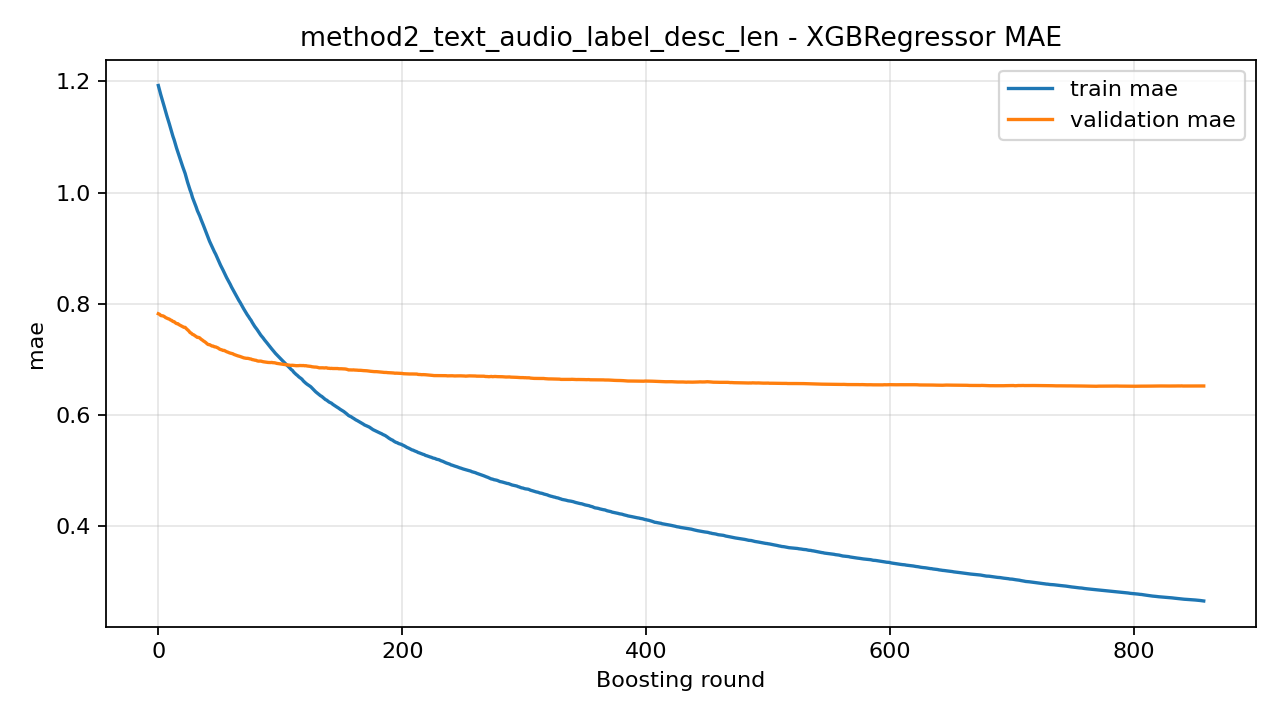

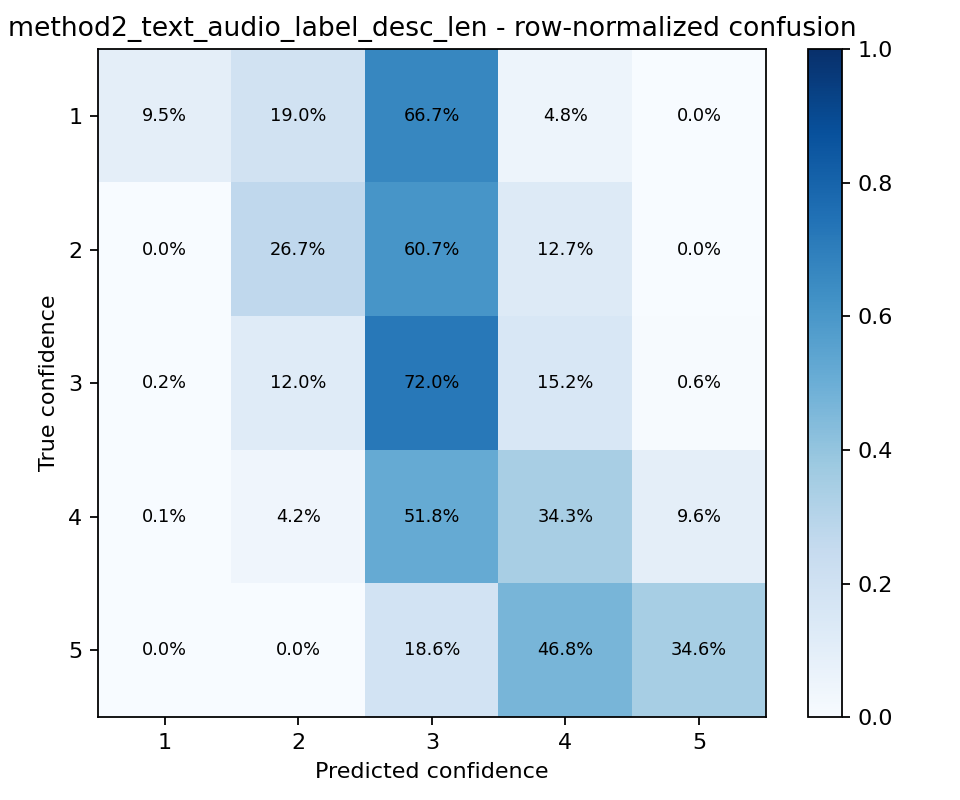

### method1_text_audio_label

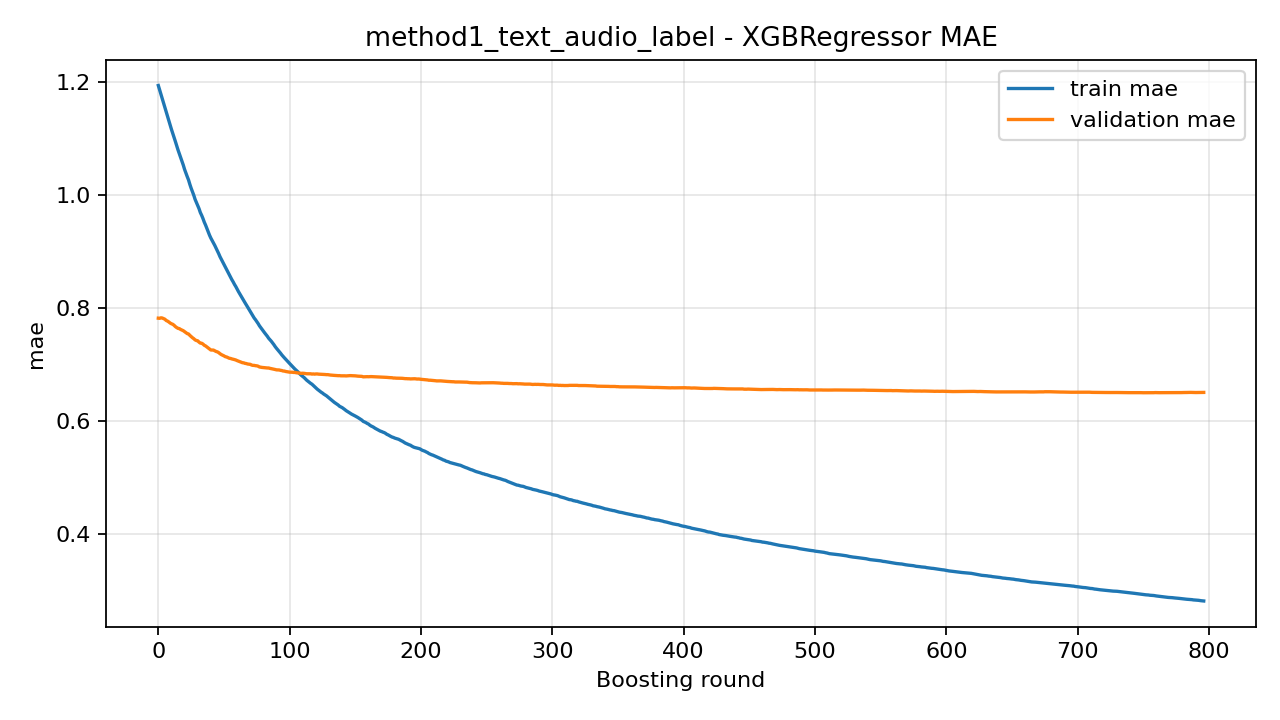

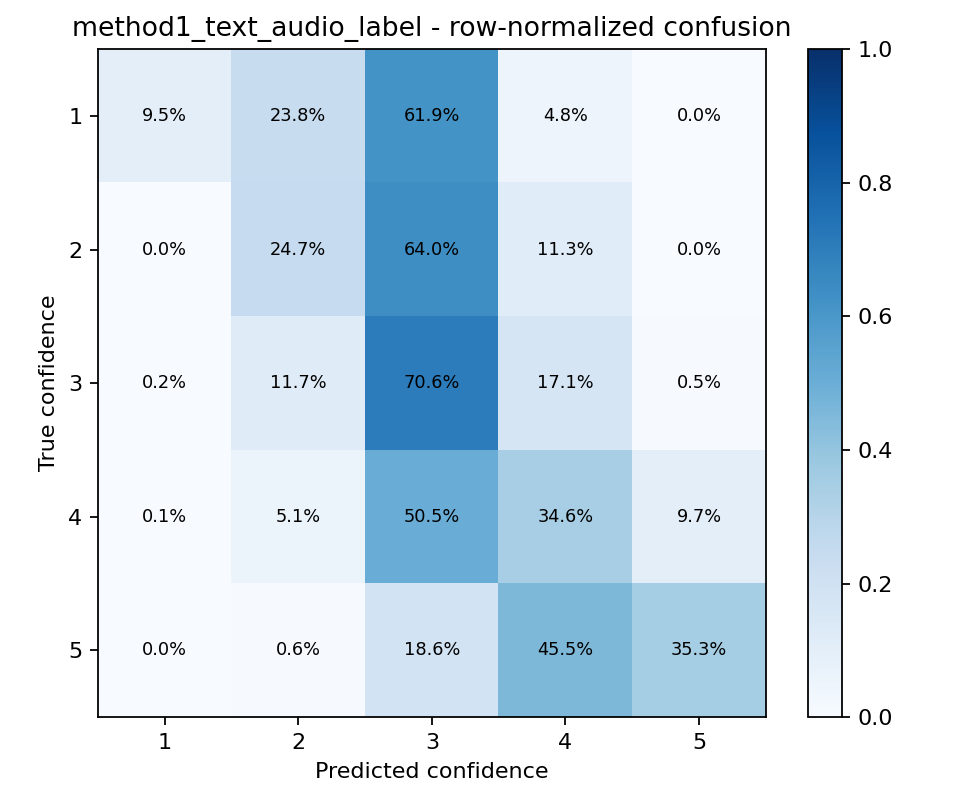

In [4]:
summary = pd.read_csv(REPORT_DIR / 'over_sample_xgboost_regression_summary.csv')
display(summary)
for feature_name in summary['feature_set']:
    display(Markdown(f'### {feature_name}'))
    display(Image(filename=str(PLOT_DIR / f'{feature_name}_train_valid_mae.png')))
    display(Image(filename=str(PLOT_DIR / f'{feature_name}_confusion_row_normalized.png')))
